# 🩸 Module 2: Diabetes Risk Prediction
**Dataset:** PIMA Indians Diabetes (UCI) via Kaggle

**Model:** XGBoost + SMOTE (handles class imbalance)

**Output:** `diabetes_model.pkl` → place in `ai-server/models/`

---

In [8]:
!pip install -q kaggle pandas numpy scikit-learn xgboost imbalanced-learn matplotlib seaborn joblib

In [9]:
# ─── STEP 2: Download Dataset ─────────────────────────────────────────────────
!kaggle datasets download -d uciml/pima-indians-diabetes-database -p ./data --unzip
!ls ./data/

Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
License(s): CC0-1.0




  0%|          | 0.00/8.91k [00:00<?, ?B/s]
100%|██████████| 8.91k/8.91k [00:00<00:00, 2.74MB/s]
'ls' is not recognized as an internal or external command,
operable program or batch file.


In [10]:
# ─── STEP 3: Load & Explore ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/diabetes.csv')
print('Shape:', df.shape)
print('\nTarget distribution:\n', df['Outcome'].value_counts())
print('\nClass balance: {:.1f}% diabetic'.format(df['Outcome'].mean()*100))
df.describe()

Shape: (768, 9)

Target distribution:
 Outcome
0    500
1    268
Name: count, dtype: int64

Class balance: 34.9% diabetic


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
# ─── STEP 4: Handle Zero Values (biologically impossible zeros) ───────────────
# Columns where 0 means missing data
import numpy as np

zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Convert to float first
df[zero_cols] = df[zero_cols].astype(float)

# Now fix zeros
for col in zero_cols:
    median_0 = df[df['Outcome']==0][col].replace(0, np.nan).median()
    median_1 = df[df['Outcome']==1][col].replace(0, np.nan).median()

    df.loc[(df[col]==0) & (df['Outcome']==0), col] = median_0
    df.loc[(df[col]==0) & (df['Outcome']==1), col] = median_1

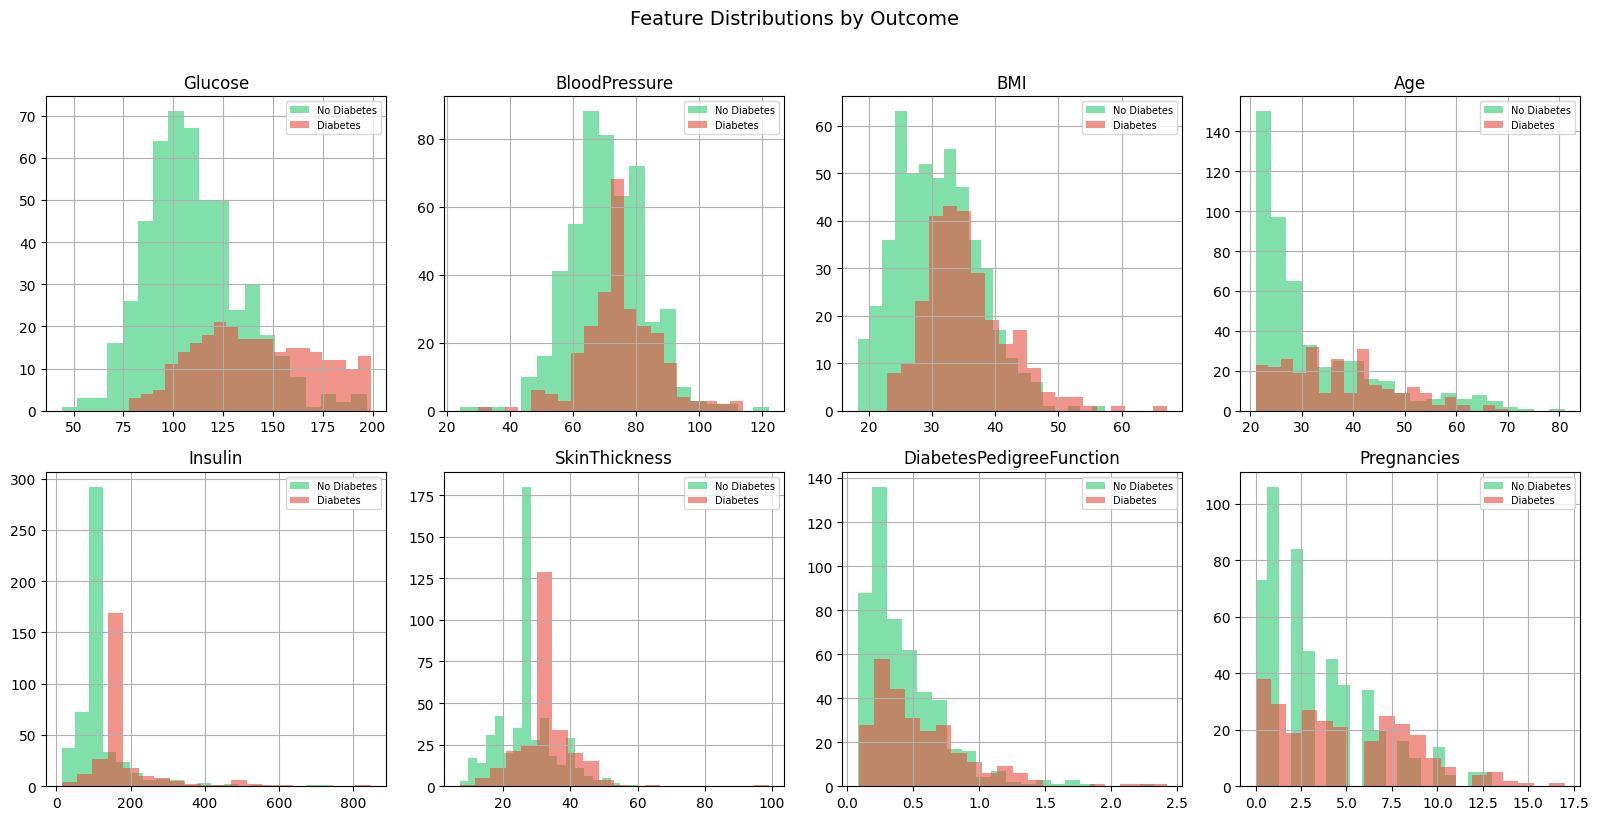

In [12]:
# ─── STEP 5: EDA ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
features = ['Glucose', 'BloodPressure', 'BMI', 'Age', 
            'Insulin', 'SkinThickness', 'DiabetesPedigreeFunction', 'Pregnancies']

for i, feat in enumerate(features):
    ax = axes[i//4][i%4]
    df[df['Outcome']==0][feat].hist(alpha=0.6, label='No Diabetes', ax=ax, color='#2ecc71', bins=20)
    df[df['Outcome']==1][feat].hist(alpha=0.6, label='Diabetes', ax=ax, color='#e74c3c', bins=20)
    ax.set_title(feat)
    ax.legend(fontsize=7)

plt.suptitle('Feature Distributions by Outcome', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('./data/diabetes_eda.png', dpi=100)
plt.show()

In [13]:
# ─── STEP 6: Feature Engineering ─────────────────────────────────────────────
# Add derived features
df['BMI_Age'] = df['BMI'] * df['Age']
df['Glucose_Insulin'] = df['Glucose'] * df['Insulin']
df['BMI_category'] = pd.cut(df['BMI'], bins=[0,18.5,25,30,100], labels=[0,1,2,3]).astype(int)
df['Glucose_category'] = pd.cut(df['Glucose'], bins=[0,99,125,200], labels=[0,1,2]).astype(int)

print('Features after engineering:', df.shape[1]-1)

X = df.drop('Outcome', axis=1)
y = df['Outcome']
FEATURE_NAMES = X.columns.tolist()
print('Feature list:', FEATURE_NAMES)

Features after engineering: 12
Feature list: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'BMI_Age', 'Glucose_Insulin', 'BMI_category', 'Glucose_category']


In [14]:
# ─── STEP 7: Handle Imbalance with SMOTE ─────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Apply SMOTE only on training data
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_sc, y_train)
print(f'After SMOTE — Class distribution: {pd.Series(y_train_sm).value_counts().to_dict()}')

After SMOTE — Class distribution: {0: 400, 1: 400}


In [15]:
# ─── STEP 8: Train & Tune XGBoost ─────────────────────────────────────────────
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
grid = GridSearchCV(xgb, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train_sm, y_train_sm)

best_model = grid.best_estimator_
print('\nBest params:', grid.best_params_)

preds = best_model.predict(X_test_sc)
proba = best_model.predict_proba(X_test_sc)[:, 1]

print(f'\nAccuracy: {accuracy_score(y_test, preds):.4f}')
print(f'AUC-ROC: {roc_auc_score(y_test, proba):.4f}')
print(classification_report(y_test, preds, target_names=['No Diabetes', 'Diabetes']))

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}

Accuracy: 0.8831
AUC-ROC: 0.9419
              precision    recall  f1-score   support

 No Diabetes       0.92      0.90      0.91       100
    Diabetes       0.82      0.85      0.84        54

    accuracy                           0.88       154
   macro avg       0.87      0.88      0.87       154
weighted avg       0.88      0.88      0.88       154



d:\HEALTH AI\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:33:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


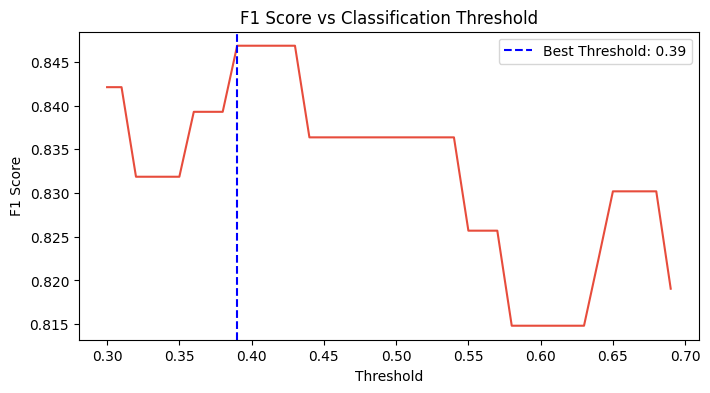


Optimal threshold: 0.39


In [16]:
# ─── STEP 9: Find Optimal Threshold ──────────────────────────────────────────
from sklearn.metrics import f1_score

thresholds = np.arange(0.3, 0.7, 0.01)
f1_scores = [f1_score(y_test, (proba >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, color='#e74c3c')
plt.axvline(best_thresh, color='blue', linestyle='--', label=f'Best Threshold: {best_thresh:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Classification Threshold')
plt.legend()
plt.savefig('./data/diabetes_threshold.png', dpi=100)
plt.show()
print(f'\nOptimal threshold: {best_thresh:.2f}')

In [17]:
# ─── STEP 10: Save Model ──────────────────────────────────────────────────────
import joblib, os
os.makedirs('./output', exist_ok=True)

bundle = {
    'model': best_model,
    'scaler': scaler,
    'feature_names': FEATURE_NAMES,
    'threshold': float(best_thresh),
    'classes': ['No Diabetes', 'Diabetes']
}

joblib.dump(bundle, './output/diabetes_model.pkl')
print('✅ Saved: ./output/diabetes_model.pkl')
print('\n📁 COPY THIS FILE TO: healthvision-ai/ai-server/models/diabetes_model.pkl')

✅ Saved: ./output/diabetes_model.pkl

📁 COPY THIS FILE TO: healthvision-ai/ai-server/models/diabetes_model.pkl


In [18]:
# ─── STEP 11: Test Prediction ─────────────────────────────────────────────────
sample = {
    'Pregnancies': 6, 'Glucose': 148, 'BloodPressure': 72, 'SkinThickness': 35,
    'Insulin': 0, 'BMI': 33.6, 'DiabetesPedigreeFunction': 0.627, 'Age': 50,
    'BMI_Age': 33.6*50, 'Glucose_Insulin': 148*0,
    'BMI_category': 2, 'Glucose_category': 2
}

loaded = joblib.load('./output/diabetes_model.pkl')
input_df = pd.DataFrame([sample])[loaded['feature_names']]
input_sc = loaded['scaler'].transform(input_df)
prob = loaded['model'].predict_proba(input_sc)[0][1]

print(f'Diabetes Risk: {prob:.4f} ({prob*100:.1f}%)')
print(f'Prediction (threshold={loaded["threshold"]:.2f}): {"❗ Diabetic" if prob >= loaded["threshold"] else "✅ Non-Diabetic"}')

Diabetes Risk: 0.1687 (16.9%)
Prediction (threshold=0.39): ✅ Non-Diabetic
